# Import Libraries

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Master Dataset

Load the master dataset generated during the preprocessing stage. This dataset contains the merged sustainability reports, ESG information, and generated claim features.

In [12]:
merged = pd.read_csv("Master_Dataset.csv")

# Remove unnecessary index column if it exists
if "Unnamed: 0" in merged.columns:
    merged = merged.drop(columns=["Unnamed: 0"])

print(merged.head())

           filename ticker  year  \
0  ASX_BSX_2020.pdf    BSX  2020   
1  ASX_BSX_2022.pdf    BSX  2022   
2  ASX_EXR_2022.pdf    EXR  2022   
3  LSE_ADM_2019.pdf    ADM  2019   
4  LSE_ADM_2020.pdf    ADM  2020   

                                preprocessed_content  \
0  style guide colour colour use imagecolour prof...   
1  sustainability report look mining green office...   
2  report environment social governance esg basel...   
3  corporate social responsibilty report introduc...   
4  sustainability admiral commit maintain respons...   

                                        ner_entities  e_score  s_score  \
0  ['bk%', 'rgb', 'un', 'el ectric mine consortiu...     3.16    18.00   
1  ['murray street', 'west perth', 'west perth', ...     2.83    12.86   
2  ['september', 'mongolia', 'australia', 'austra...     3.81     4.28   
3  ['david stevens', 'csr board', 'just over  yea...    16.38    14.20   
4  ['year', 'health & wellbeing', 'a -month', 'on...    15.89    13.51   

 

# Create ESG Risk Comparison Table

In [13]:
rq2 = merged.groupby('claim_type')['Total ESG Risk score'].mean()

print(rq2)

claim_type
Concrete    20.710092
Vague       21.629920
Name: Total ESG Risk score, dtype: float64


# Visualize ESG Risk Comparison

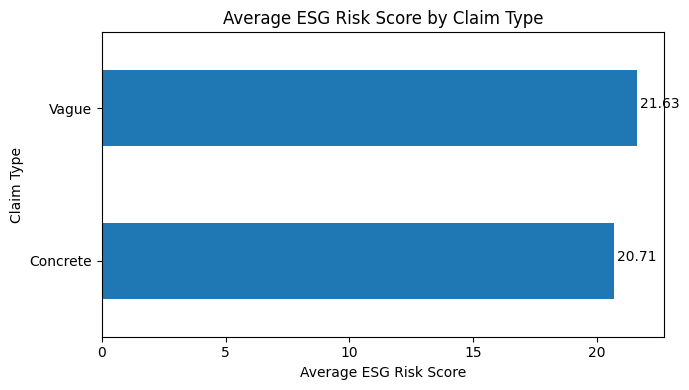

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

ax = rq2.sort_values().plot(kind='barh')

plt.title("Average ESG Risk Score by Claim Type")
plt.xlabel("Average ESG Risk Score")
plt.ylabel("Claim Type")

# Add values on bars
for i, value in enumerate(rq2.sort_values()):
    plt.text(value + 0.1, i, f"{value:.2f}")

plt.tight_layout()

plt.savefig("RQ2_ESG_Risk_vs_Claim_Type.pdf")

plt.show()

# Save Figure and Table

In [16]:
# Save table
rq2.to_csv(
    "RQ2_ESG_Risk_vs_Claim_Type.csv",
    header=True
)

# Save chart
plt.savefig(
    "RQ2_ESG_Risk_vs_Claim_Type.pdf",
    bbox_inches='tight'
)

print("RQ2 outputs saved successfully.")

RQ2 outputs saved successfully.


<Figure size 640x480 with 0 Axes>